In [1]:
import matplotlib.pyplot as plt
import csv
from collections import defaultdict
def get_APD(lib, dt,APD_percentage = 0.3): # lib is 2D array, each row is a time series of one pixel
    def linear_interpolation(y0,y1,x0,x1,x):
        
        return (y0 * (x1-x) + y1 * (x-x0)) / (x1-x0)
    APD = defaultdict(list)
    for key in lib:

        APD[key] = []

        APD_value = 0
        start_apd = False
        for j in range(len(lib[key])):


            if start_apd == False and lib[key][j] > APD_percentage:
                start_apd = True
                if j == 0:
                    APD_start_error = 0
                else:
                    APD_start_error = linear_interpolation(1,0,lib[key][j],lib[key][j-1],APD_percentage)
                    APD_start_error = 1 - APD_start_error
                
            if start_apd == True and lib[key][j] <= APD_percentage: 
                start_apd = False
                APD_end_error = linear_interpolation(0,-1,lib[key][j],lib[key][j-1],APD_percentage)
                
                APD_value += (APD_start_error + APD_end_error) * dt                
                APD[key].append(APD_value)
                APD_value = 0
                APD_start_error = -100
                APD_end_error = -100
            if start_apd == True:
                APD_value += dt
    return APD

In [ ]:
# Create an 8x10 grid (80 slots for 75 images)
fig, axs = plt.subplots(8, 10, figsize=(20, 16))

# Flatten the grid to a single list for easy looping
for i, ax in enumerate(axs.flat):
    if i < 75:
        try:
            # Generate path for Na = 0.1 to 7.5
            path = rf"C:\Users\xan37\Downloads\C_Na_{(i+1)/10:.2f}_time_1000_0.8_0.8.png"
            img = plt.imread(path)
            
            # Show image with your specific coordinate extent
            ax.imshow(img, extent=[0, img.shape[1], 0, img.shape[0]])
            ax.set_title(f"Na={(i+1)/10:.1f}", fontsize=8)
        except: pass
    
    ax.axis('off') # Hide axis lines for cleanness

plt.tight_layout()
plt.savefig("TNNP_Na_Variation.png", dpi=300)

In [52]:
# read csv
csv_file = r".\result_Na_test.csv"
step = None
voltage = {}
with open(csv_file, 'r') as file:
    reader = csv.reader(file, delimiter=',')
    cur_v = []
    for row in reader:
        if len(row) == 1:
            key = round(float(row[0]), 3) # float to digit 2
            voltage[key] = cur_v
            continue
        cur_v = [float(v) for v in row if v]
# APD = get_APD(voltage, dt=step, APD_percentage=0.3)



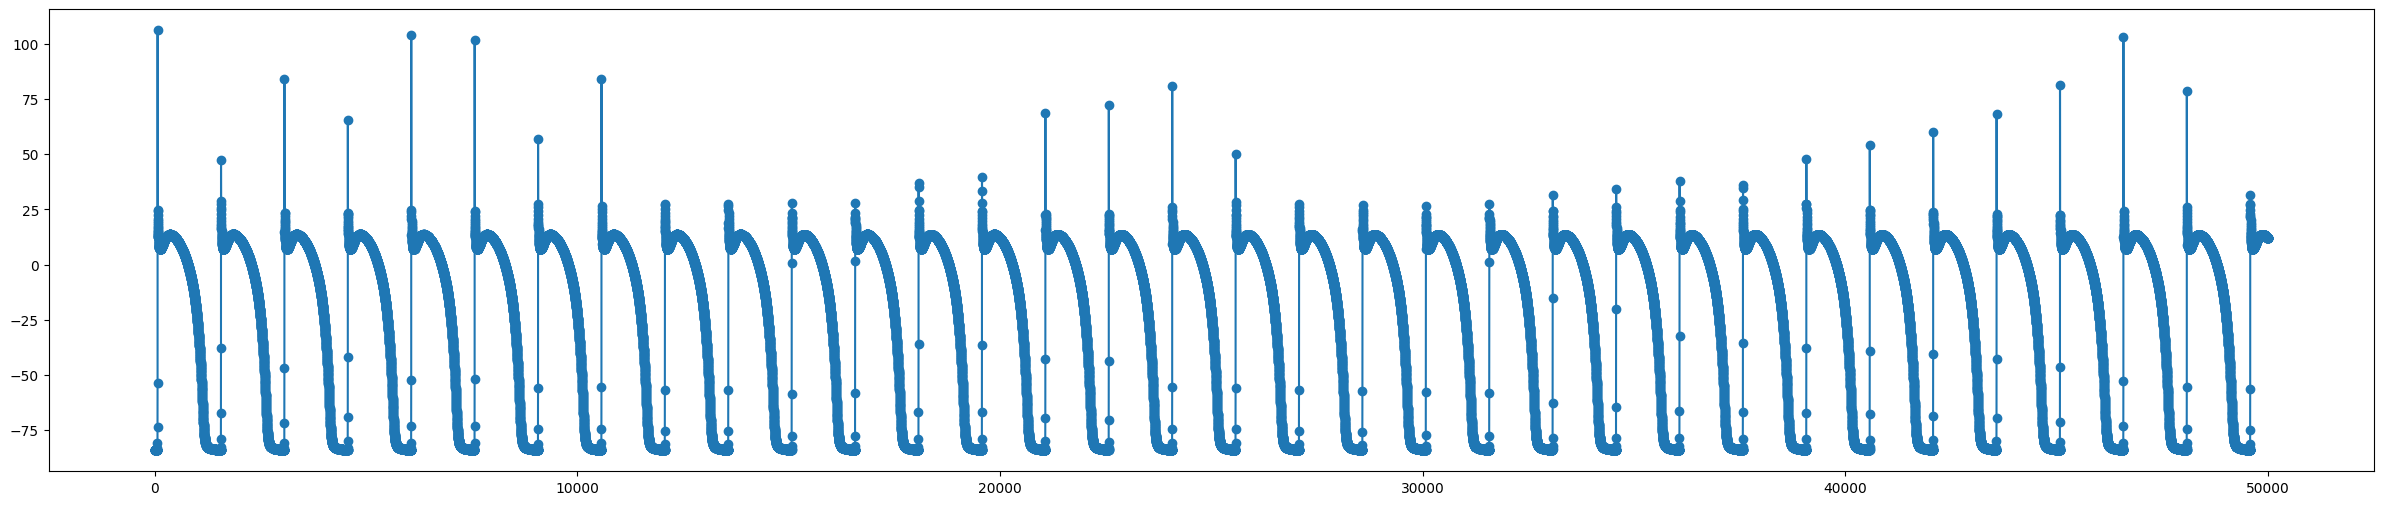

In [56]:
plt.figure(figsize=(30,6))
plt.plot(voltage[7.5],'-o')

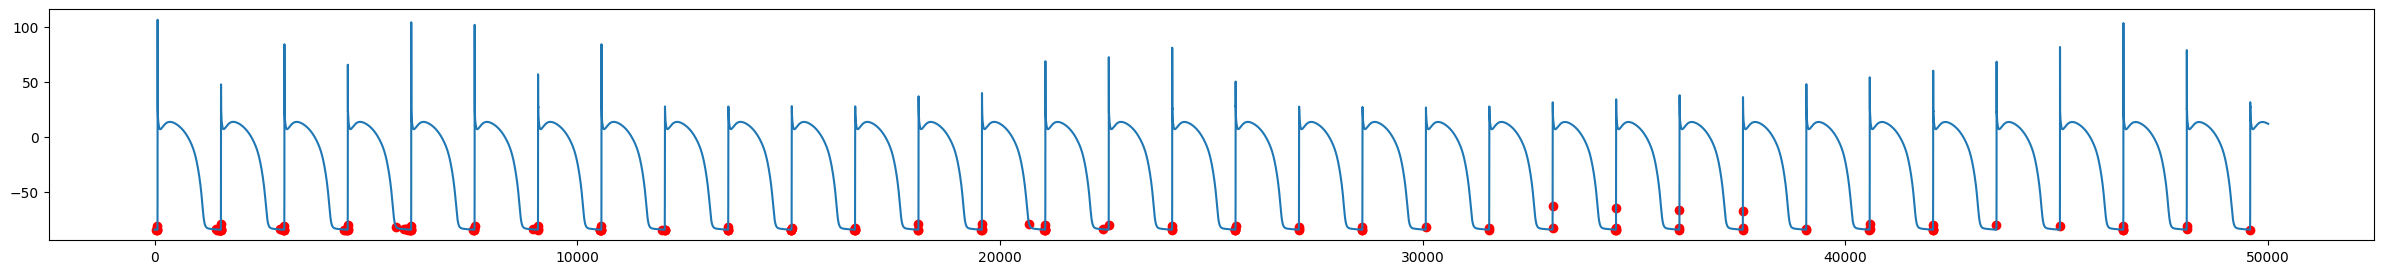

In [ ]:
#seperate action potential of a given voltage signal
# it should start when dv/dt begins > 0 and v < 0
# it should end when next start
# deleat first/last AP if incomplete
# output APs and all startiing indexes
def get_AP(voltage_signal):
    APs = []
    current_AP = []
    in_AP = False
    for i in range(1, len(voltage_signal)):
        dv_dt = voltage_signal[i] - voltage_signal[i-1]
        if not in_AP:
            if dv_dt > 0.001 and voltage_signal[i] < 0:
                in_AP = True
                current_AP = [voltage_signal[i-1], voltage_signal[i]]
        else:
            current_AP.append(voltage_signal[i])
            if i + 1 < len(voltage_signal):
                next_dv_dt = voltage_signal[i+1] - voltage_signal[i]
                if next_dv_dt > 0 and voltage_signal[i+1] < 0:
                    in_AP = False
                    APs.append(current_AP)
                    current_AP = []
    return APs, [voltage_signal.index(AP[0]) for AP in APs]
APs, starting_indexes = get_AP(voltage[7.5])
plt.figure(figsize=(30,3))
# now plot each starting point based on their index, plot points not lines
for start_idx in starting_indexes:
    plt.plot(start_idx, voltage[7.5][start_idx], 'ro')
plt.plot(voltage[7.5])


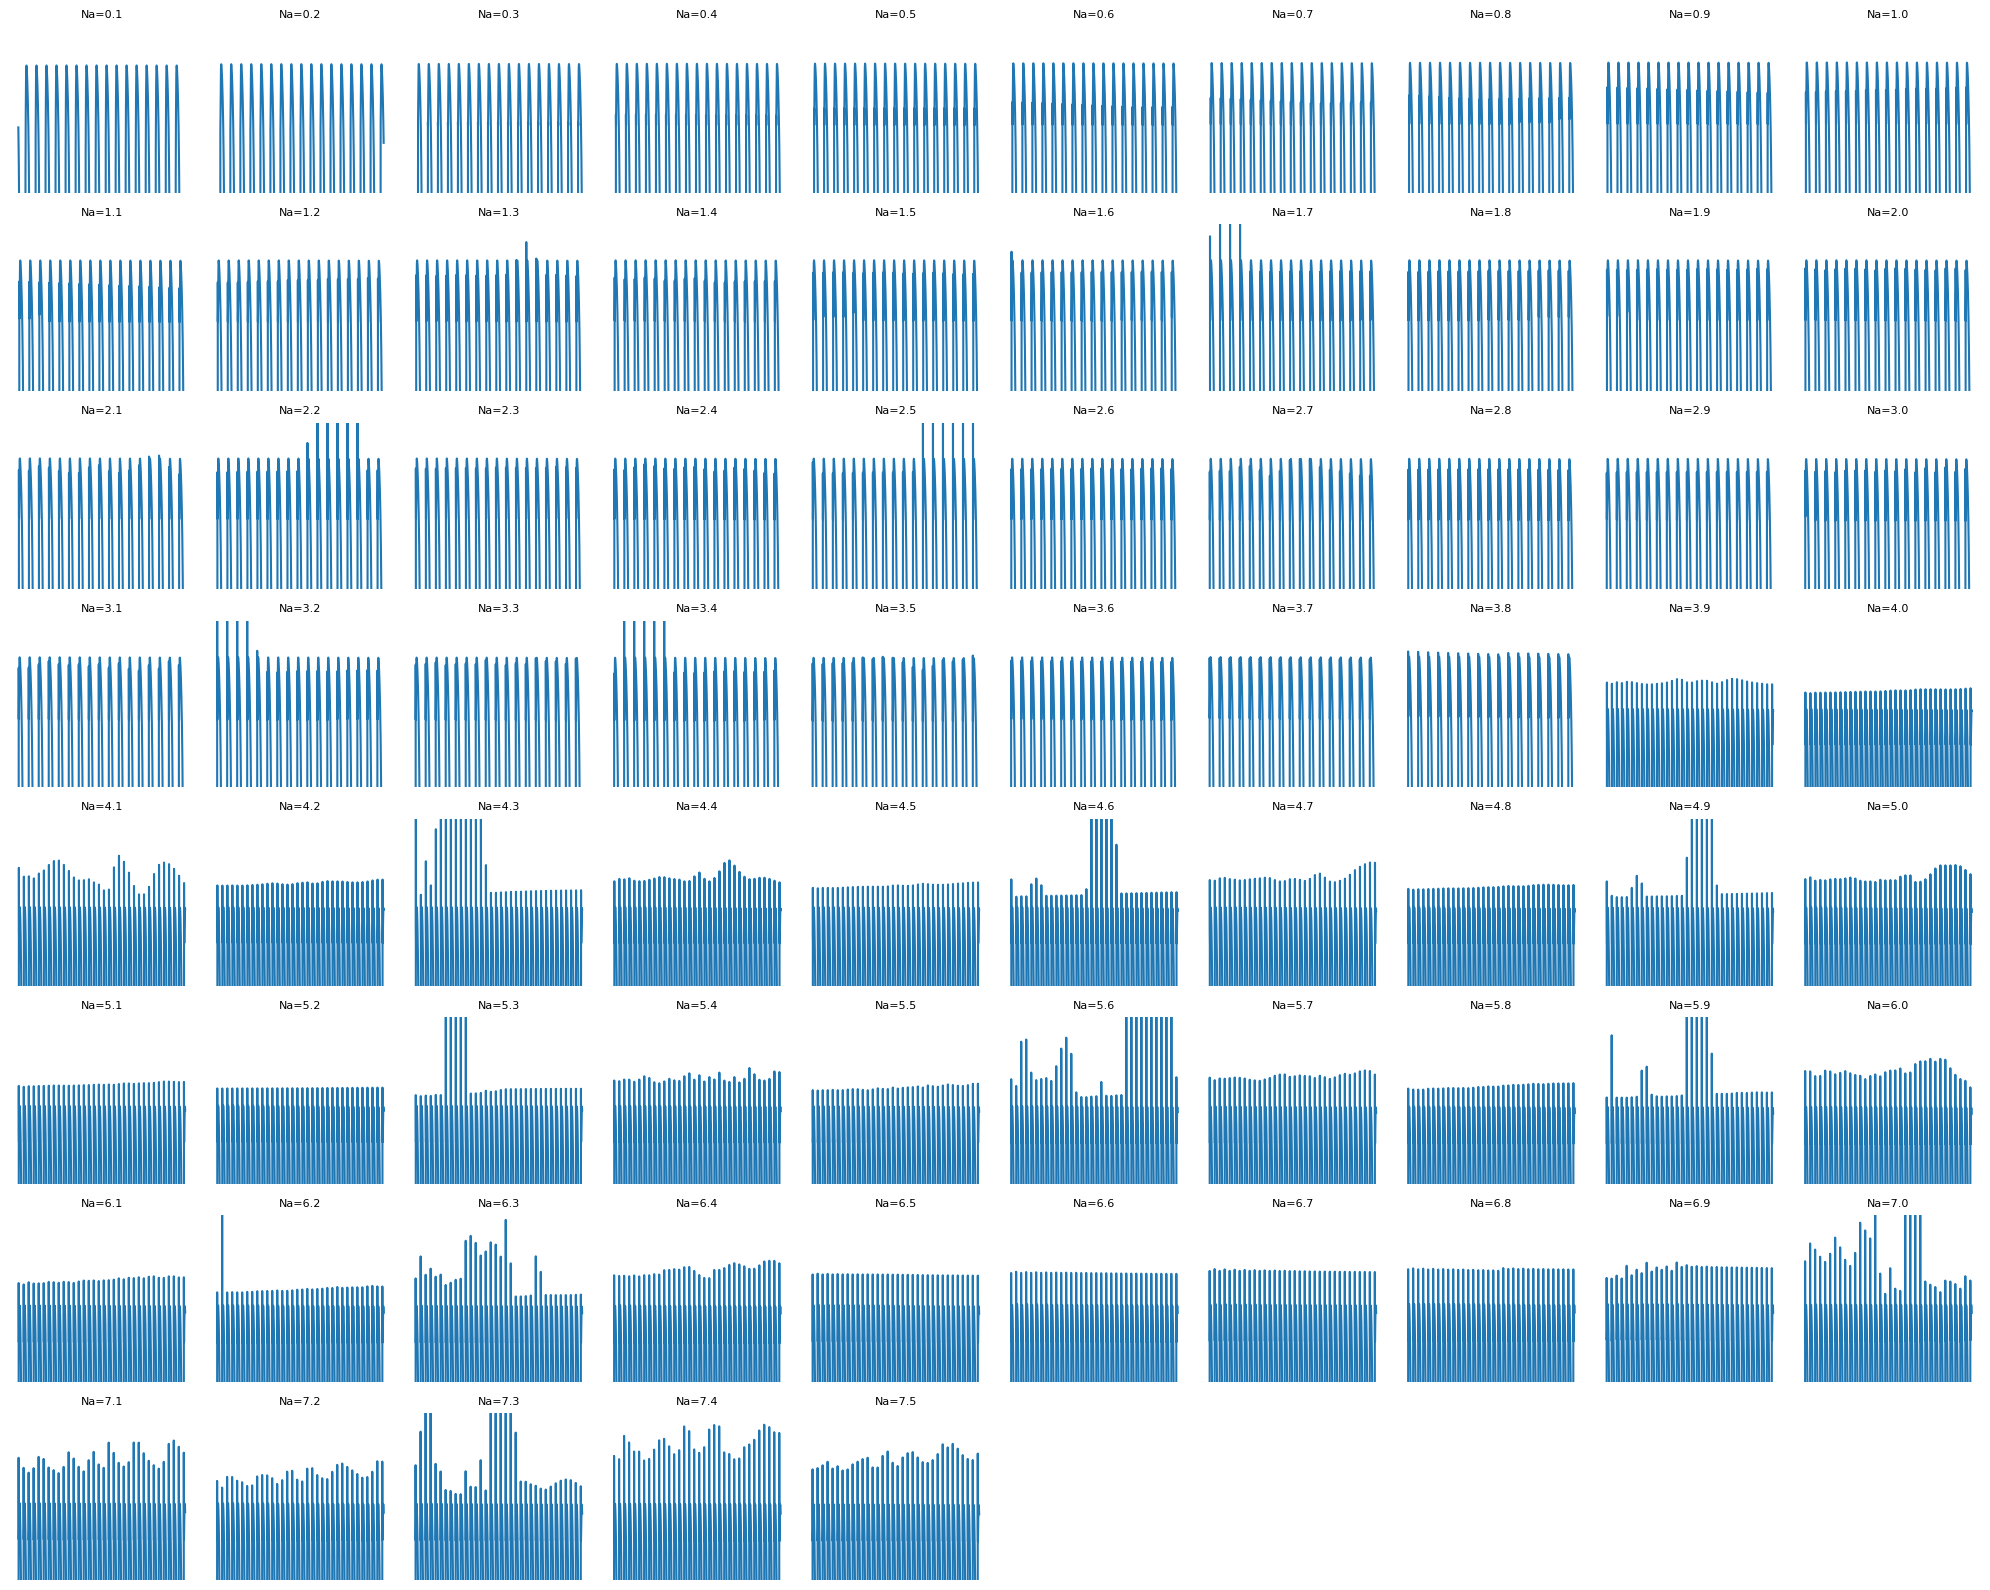

In [39]:


# 1. Create an 8x10 grid (80 slots for 75 plots)
fig, axs = plt.subplots(8, 10, figsize=(20, 16))

# Start the 'Na' key value
key_Na = 0.1

# 2. Flatten the grid to a single list for easy looping
# Enumerate over the 80 subplot axes in the flattened array
for i, ax in enumerate(axs.flat):
    
    # We only want to plot in the first 75 subplots
    if i < 75:
        # Check if the data for the current key exists
        if key_Na in voltage:
            
            # --- 🎯 THE FIX ---
            # Use ax.plot() directly on the subplot axis object to draw a line graph.
            ax.plot(voltage[key_Na], color='C0')
            ax.set_ylim(0,30)
            # Set the title with the current Na value
            ax.set_title(f"Na={key_Na:.1f}", fontsize=8)
            
            # Optional: Customize axes for line plots
            ax.set_xticks([]) # Remove x-ticks
            ax.set_yticks([]) # Remove y-ticks
            
            # Increment the key for the next subplot
            key_Na += 0.1
            key_Na = round(key_Na, 1) # Use round to prevent floating point errors
        
        else:
            # Handle case where the expected data key is missing (optional)
            ax.text(0.5, 0.5, "Data Missing", transform=ax.transAxes, ha='center')
            
    # Always turn off the axis for all subplots for a clean look
    ax.axis('off')

# 3. Adjust layout and display
plt.tight_layout()
plt.show()
# plt.savefig("TNNP_Na_Variation.png", dpi=300)